<a href="https://colab.research.google.com/github/karolalonso70-dev/Estad-sticaVerano2026/blob/main/gymmemberss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd

df = pd.read_csv("/content/gym_members_exercise_tracking.csv")

display(df.head())

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

In [24]:
df.dropna(inplace=True)

The DataFrame `df` contains the following columns relevant for analysis:

*   `Age`
*   `Gender`
*   `Weight (kg)`
*   `Height (m)`
*   `Max_BPM`
*   `Avg_BPM`
*   `Resting_BPM`
*   `Session_Duration (hours)`
*   `Calories_Burned`
*   `Workout_Type`
*   `Fat_Percentage`
*   `Water_Intake (liters)`
*   `Workout_Frequency (days/week)`
*   `Experience_Level`
*   `BMI`

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1   group2  meandiff p-adj   lower  upper  reject
-------------------------------------------------------
  Cardio     HIIT  -0.1757 0.9918  -1.751 1.3995  False
  Cardio Strength  -0.8341 0.4882 -2.3476 0.6795  False
  Cardio     Yoga  -0.8325  0.507 -2.3756 0.7107  False
    HIIT Strength  -0.6583 0.7028 -2.2293 0.9127  False
    HIIT     Yoga  -0.6567  0.716 -2.2563 0.9428  False
Strength     Yoga   0.0016    1.0 -1.5372 1.5404  False
-------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

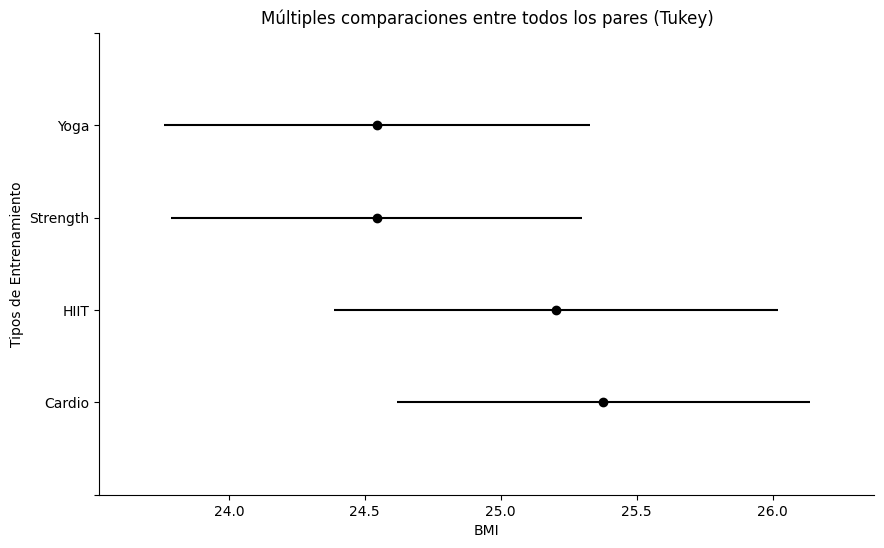

In [25]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['BMI'], # Variable de respuesta
    groups=df['Workout_Type'],  # Variable categorica nominal (assuming this is the intended grouping variable)
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Tipos de Entrenamiento", xlabel="BMI") # Adjusted labels to match the data

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [26]:
df['Gender_Encoded'] = df['Gender'].map({'Female': 0, 'Male': 1})
display(df.head())

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Gender_Encoded
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20,1
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00,0
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71,0
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41,1
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39,1


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

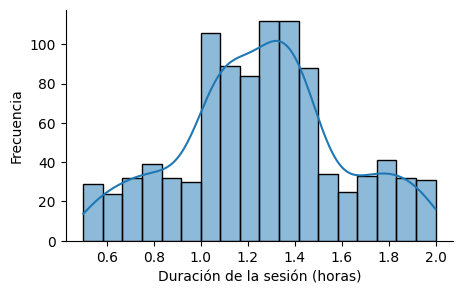

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['Session_Duration (hours)'], kde=True)
plt.xlabel("Duración de la sesión (horas)")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

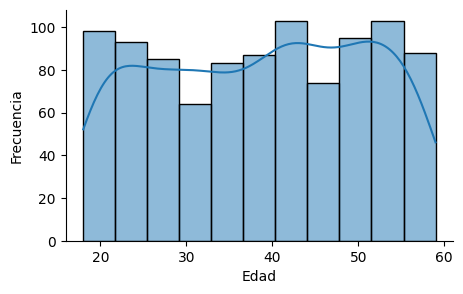

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['Age'], kde=True)
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

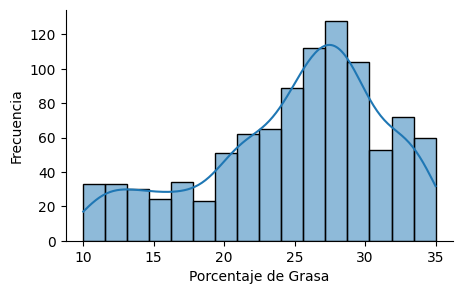

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma de 'Fat_Percentage'
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['Fat_Percentage'], kde=True)
plt.xlabel("Porcentaje de Grasa")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

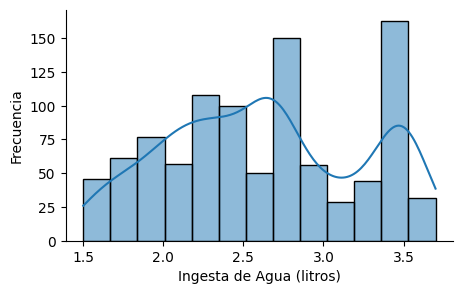

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma de 'Water_Intake (liters)'
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['Water_Intake (liters)'], kde=True)
plt.xlabel("Ingesta de Agua (litros)")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

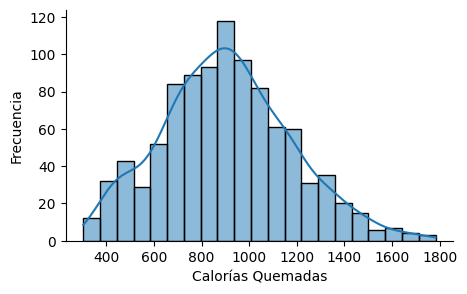

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma de 'Calories_Burned'
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['Calories_Burned'], kde=True)
plt.xlabel("Calorías Quemadas")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

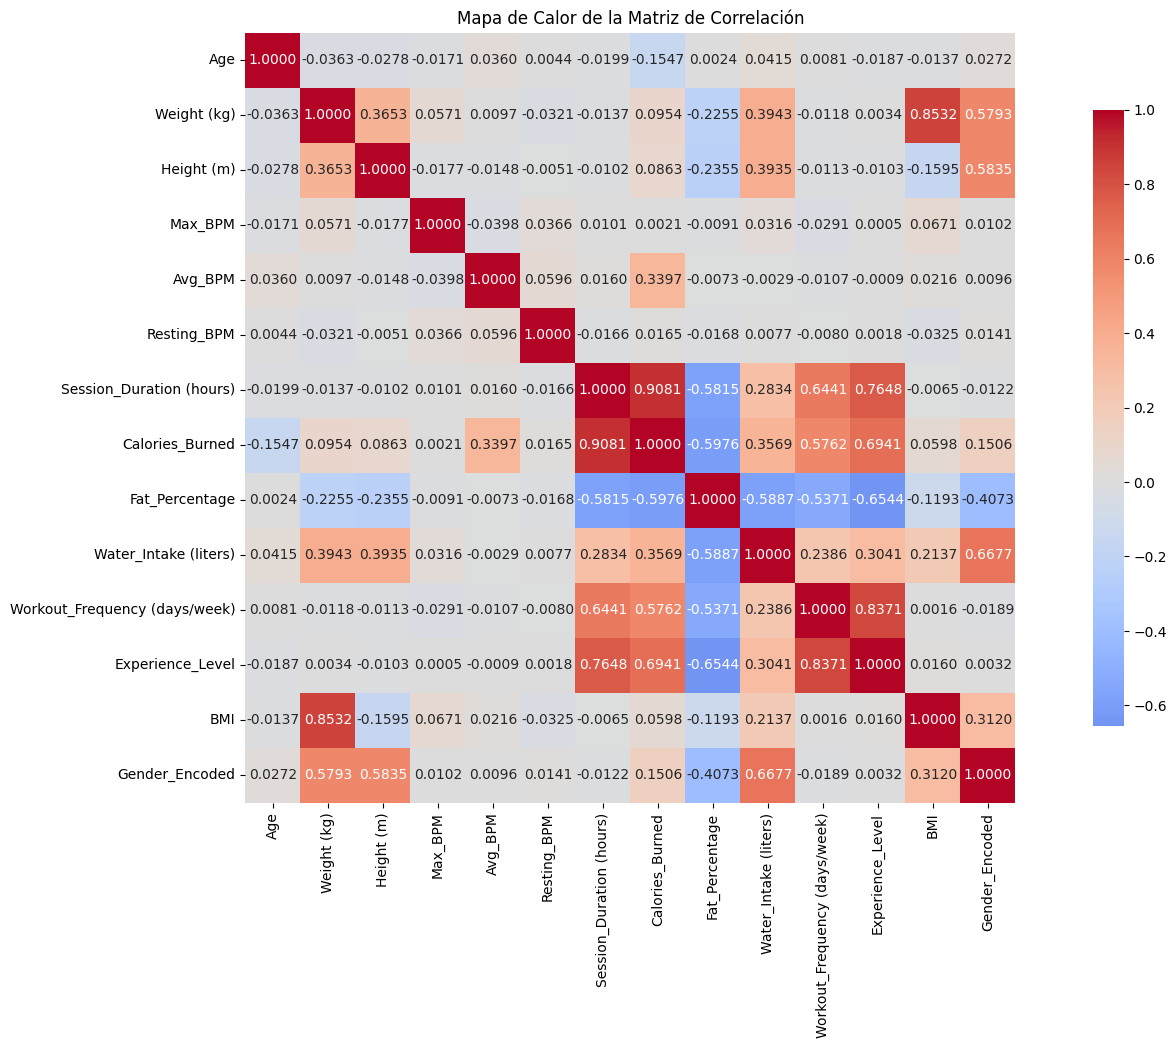

In [34]:
import seaborn as sns          # Librería para visualización estadística
import matplotlib.pyplot as plt  # Librería base para gráficos

# Selecciona solo las columnas numéricas del DataFrame para calcular la matriz de correlación
correlation_matrix = df.select_dtypes(include=['number']).corr()

plt.figure(
    figsize=(20, 10), # Define el tamaño de la figura (ancho, alto)
    dpi = 100  # Calidad de la imagen dpi=50 (estandar) dpi = 300 (alta calidad)
    )

# Construye el mapa de calor de la matriz de correlación
sns.heatmap(
    correlation_matrix,   # Datos: matriz de correlación
    annot=True,           # Muestra los valores numéricos en cada celda
    cmap='coolwarm',      # Paleta de colores (azul = negativo, rojo = positivo)
    fmt=".4f",            # Formato de los números (4 decimales)
    square=True,          # Hace que cada celda sea cuadrada
    center=0,             # Centra la escala de colores en 0 (muy importante)
    cbar_kws={"shrink": .8}  # Reduce el tamaño de la barra de color
)

# Título del gráfico
plt.title('Mapa de Calor de la Matriz de Correlación')

# Muestra la gráfica en pantalla
plt.show()

In [35]:
X = df["Session_Duration (hours)"]
Y = df["Calories_Burned"]

In [36]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

In [37]:
# Coeficiente de determinación
from sklearn.metrics import r2_score

r2 = r2_score(Y, y_calculada)

print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  82.47%


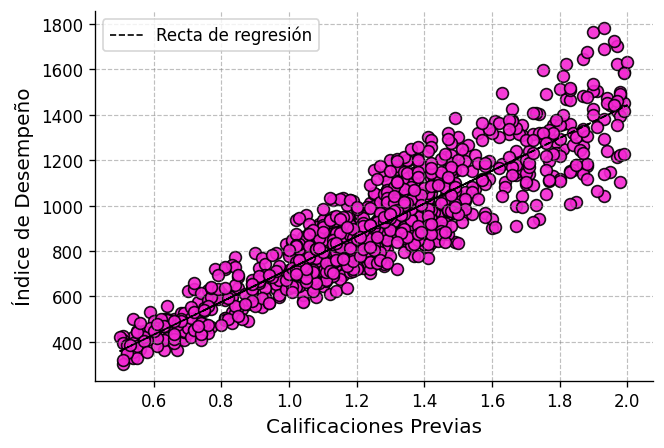

In [38]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='#F527D3',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Calificaciones Previas', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Índice de Desempeño', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    loc='best',
    fontsize=10
)

In [39]:
residuales = modelo.resid

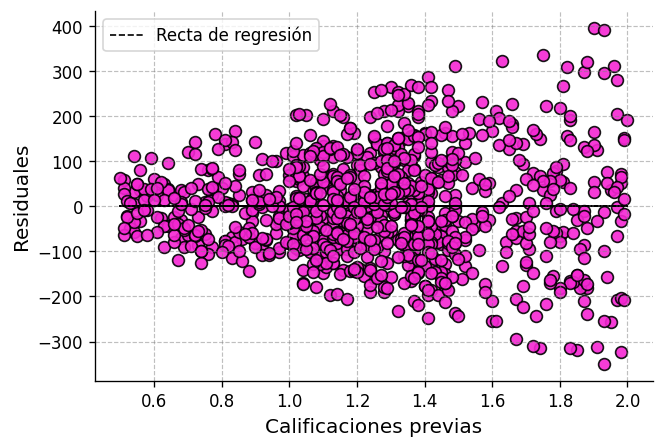

In [40]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, residuales,      # <--------------------------------------------------------
    marker="o",       # forma: googlear "matplotlib.markers"
    color='#F527D3',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada * 0,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Calificaciones previas', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Residuales', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    fontsize=10,
    loc='best'
)

valor-p (Shapiro) = 0.003841645423152361


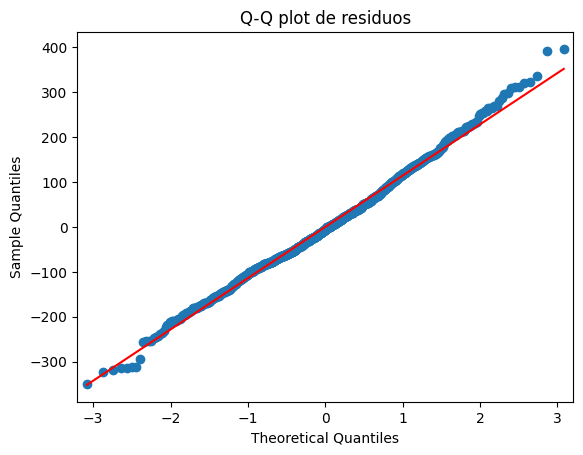

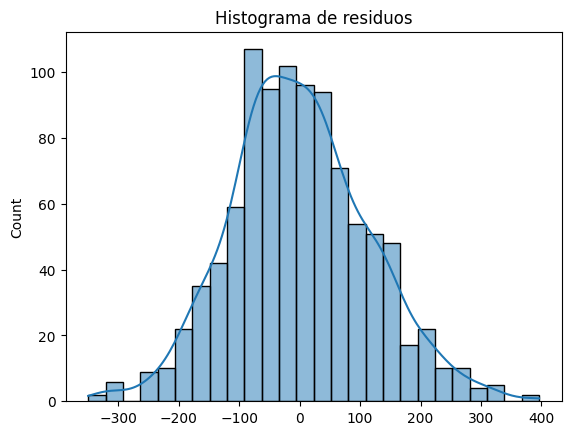

In [41]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# n < 30, Shapiro-Wilk es el más confiable
# n >= 30, Histograma o Q-Q plot

# test de Shapiro-Wilk
1
# H0: Hay normalidad    0.4172971767713699
0.05
# H1: No hay normalidad
0

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [42]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.0000



In [43]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X (using Q() for column names with spaces)
modelo_lineal = ols('Q("Calories_Burned") ~ Q("Session_Duration (hours)")',data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
"Q(""Session_Duration (hours)"")",1.0,5.958764e+07,5.958764e+07,4568.674447,0.0
Residual,971.0,1.266442e+07,1.304265e+04,NaN,NaN


In [44]:
X = df[["Session_Duration (hours)", "Workout_Frequency (days/week)"]]
Y = df["Calories_Burned"]

In [45]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

In [46]:
# Coeficiente de determinación
from sklearn.metrics import r2_score

r2 = r2_score(Y, y_calculada)

print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  82.49%
